UTS BIG DATA - MANIPULASI DATA & VISUALISASI <br>

NAMA : Bifaqih Zulfa<br>
NIM : 12231945<br>
PRODI : Informatika<br>


JAWABAN SOAL A - NO.1
Jumlah baris data Yogyakarta : 20004 baris
Jumlah baris data Magelang   : 3845 baris
Jumlah total seluruh baris setelah digabung: 23849 baris

JAWABAN SOAL A - NO.2
Jumlah baris sebelum outliers dibuang : 23849
Jumlah baris setelah outliers dibuang : 21349
Total data outliers yang dihapus      : 2500 baris

JAWABAN SOAL A - NO.3
Jumlah missing value di setiap kolom:
tanggal    4
kode       5
nama       4
jumlah     5
harga      0
area       0
dtype: int64
Total seluruh missing value dalam dataset: 18 data

JAWABAN SOAL A - NO.4
Jumlah data duplikat mula-mula: 6842
Jumlah baris akhir dataset setelah deduplikasi: 14507 baris

JAWABAN SOAL B - VISUALISASI


/tmp/ipykernel_4016/1553931191.py:59: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_telur['tanggal'] = pd.to_datetime(df_telur['tanggal'], errors='coerce')


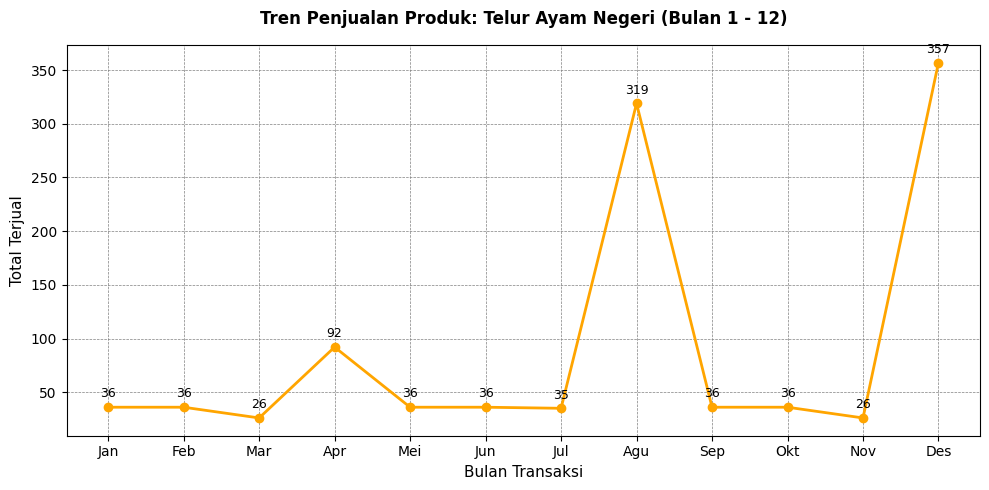

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# [SOAL A] - NOMOR 1: PENGGABUNGAN DATASET & JUMLAH BARIS
url_yk = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_yk.csv"
url_mgl = "https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_ritel_mgl.csv"

# Membaca berkas data asli
df_yk = pd.read_csv(url_yk)
df_mgl = pd.read_csv(url_mgl)

# Menggabungkan kedua dataset secara vertikal
df_gabungan = pd.concat([df_yk, df_mgl], ignore_index=True)

print("JAWABAN SOAL A - NO.1")
print(f"Jumlah baris data Yogyakarta : {df_yk.shape[0]} baris")
print(f"Jumlah baris data Magelang   : {df_mgl.shape[0]} baris")
print(f"Jumlah total seluruh baris setelah digabung: {df_gabungan.shape[0]} baris\n")

# [SOAL A] - NOMOR 2: REMOVING OUTLIERS (KOLOM 'harga')
# Menghitung IQR menggunakan kolom 'harga' (huruf kecil)
Q1 = df_gabungan['harga'].quantile(0.25)
Q3 = df_gabungan['harga'].quantile(0.75)
IQR = Q3 - Q1

# Menetapkan batas bawah dan batas atas pencilan
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menyaring data yang berada di dalam batas aman
df_clean = df_gabungan[(df_gabungan['harga'] >= lower_bound) & (df_gabungan['harga'] <= upper_bound)].copy()

print("JAWABAN SOAL A - NO.2")
print(f"Jumlah baris sebelum outliers dibuang : {df_gabungan.shape[0]}")
print(f"Jumlah baris setelah outliers dibuang : {df_clean.shape[0]}")
print(f"Total data outliers yang dihapus      : {df_gabungan.shape[0] - df_clean.shape[0]} baris\n")

# [SOAL A] - NOMOR 3: CHECKING MISSING VALUE
print("JAWABAN SOAL A - NO.3")
print("Jumlah missing value di setiap kolom:")
print(df_clean.isna().sum())
print(f"Total seluruh missing value dalam dataset: {df_clean.isna().sum().sum()} data\n")

# [SOAL A] - NOMOR 4: CHECKING DUPLIKASI & DEDUPLIKASI
print("JAWABAN SOAL A - NO.4")
print(f"Jumlah data duplikat mula-mula: {df_clean.duplicated().sum()}")

# Melakukan proses penghapusan data duplikat (Deduplikasi)
df_final = df_clean.drop_duplicates().copy()
print(f"Jumlah baris akhir dataset setelah deduplikasi: {df_final.shape[0]} baris\n")

# [SOAL B] - VISUALISASI LINE CHART (KOLOM 'nama' & 'tanggal')
print("JAWABAN SOAL B - VISUALISASI")

# 1. Filter data khusus untuk produk "Telur Ayam Negeri" pada kolom 'nama'
df_telur = df_final[df_final['nama'] == 'Telur Ayam Negeri'].copy()

# 2. Konversi kolom 'tanggal' ke tipe datetime dan ekstrak angka bulannya
df_telur['tanggal'] = pd.to_datetime(df_telur['tanggal'], errors='coerce')
df_telur['Bulan_Angka'] = df_telur['tanggal'].dt.month

# 3. Hitung total kuantitas penjualan (kolom 'jumlah') per bulan (1 sampai 12)
tren_bulanan = df_telur.groupby('Bulan_Angka')['jumlah'].sum().reindex(range(1, 13), fill_value=0)

# 4. Membuat Line Chart
plt.figure(figsize=(10, 5))
nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

plt.plot(nama_bulan, tren_bulanan.values, marker='o', color='orange', linewidth=2, linestyle='-')

# 5. Atribut Tambahan Grafik
plt.title("Tren Penjualan Produk: Telur Ayam Negeri (Bulan 1 - 12)", pad=15, fontsize=12, fontweight='bold')
plt.xlabel("Bulan Transaksi", fontsize=11)
plt.ylabel("Total Terjual", fontsize=11)
plt.grid(color='gray', linestyle='--', linewidth=0.5)

# Menampilkan angka kuantitas tepat di atas titik plot (Data Label)
for i, nilai in enumerate(tren_bulanan.values):
    if nilai > 0:
        plt.annotate(f'{int(nilai)}', (nama_bulan[i], tren_bulanan.values[i]), textcoords="offset points", xytext=(0,7), ha='center', fontsize=9)

plt.tight_layout()
plt.show()